
<center><h1><font color='darkblue'>Elektrotehnički fakultet Beograd, RMFP & PF2</font></h1></center>

# ispit 22.10.2025.

***
<font color='green'>
    <p style='text-align: center;'>Luka Puco 24/0091</p>
</font>    

<font color='red'>Preimenovati svesku u Ime_Prezime</font>

#### __Zadatak__: Prinudne oscilacije sa promenljivom silom
a) Posmatra se LHO (linearni harmonijski oscilator) u formi tega mase $m$ na ravnom stolu. Sa jedne strane teg je vezan za zid oprugom krutosti $k$, dok je sa druge strane vezan amortizer faktora prigušenja $\alpha$. U sistemu postoji i motor koji proizvodi prinudnu sila u obliku $F = F_0sin(\omega t)$, gde je  $F_0$ amplituda sile, a  $\omega$  je ugaona frekvencija prinudne sile. Do vremenskog trenutka $t_1$ sistem osciluje bez prinudne sile. U vremenskom trenutku $t_1$ na sistem počinje da deluje prinudna sila amplitude $F_{01}$, a u vremenskom trenutku $t_2$ amplituda prinudne sile se menja i uzima vrednost $F_{02}$. 

Napisati Python definiciju koja predstavlja opisani sistem, a koja za pozivne parametre ima masu tega, sopstvenu kružnu učestanost, faktor prigušenja, ugaonu frekvenciju prinudne sile, odgovarajuće vrednosti amplitude prinudne sile i  vremenske trenutke $t_1$ i $t_2$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
def lho(y,t,omega0,alpha,omegaPrinudno,t1,t2,m,F01,F02):
    y1,y2=y
    if t<t1:
        return [y2, -(omega0**2)*y1 - 2*alpha*y2]
    elif t1<t<t2:
        return[y2,F01/m*np.sin(omegaPrinudno*t)-(omega0**2)*y1 - 2*alpha*y2]
    else:
        return[y2,F02/m*np.sin(omegaPrinudno*t)-(omega0**2)*y1 - 2*alpha*y2]

b) Sistem je izveden iz ravnotežnog stanja za $5$ cm bez početne brzine, masa tega je $m = 2$ kg, konstanta krutosti opruge iznosi $k = 50$ N/cm, dok je faktor prigušenja $\alpha = \omega_0/40$, gde je $\omega_0 = \sqrt{k/m}$ sopstvena kružna učestanost oscilatora. Vremenski trenuci $t_1$ i $t_2$ (u kojima dolazi do pojave, a zatim i promene amplitude prinudne sile) iznose $10$ s i $20$ s, respektivno. Amplitude prinudne sile su $F_{01} = 10$ i $F_{02} = 20$ N, dok je ugaona frekvencija prinudne sile konstantna i iznosi $\omega = 5$ rad/s.

Napisati glavni program koji na osnovu datih vrednosti iscrtava vremenski dijagram $x(t)$ i fazni dijagram $v(x)$ oscilovanja u okviru jednog subplot grafika sa dve ćelije (u jednu ćeliju smestiti vremenski, a u drugu fazni dijagram). Svaka ćelija subplot grafika treba da ima obeležene ose i odgovarajući naslov. Na grafike u okviru svake ćelije dodati mrežu (grid). Na vremenskom dijagramu proizvoljnim markerima različite boje obeležiti vrednosti elongacija, odnosno tačke $x_1 = x(t_1)$ i $x_2 = x(t_2)$ u trenucima $t_1$ i $t_2$. Na faznom dijagramu proizvoljnim markerima različite boje obeležiti vrednosti brzina $v_1 = v(x_1)$ i $v_2 = v(x_2)$. Dodatno, ispod grafika, program treba da ispiše vrednosti za $x_1, x_2, v_1$ i $v_2$.

Vremensku osu napraviti kao niz brojeva od $0$ do $45$ s sa korakom $0.01$ s.

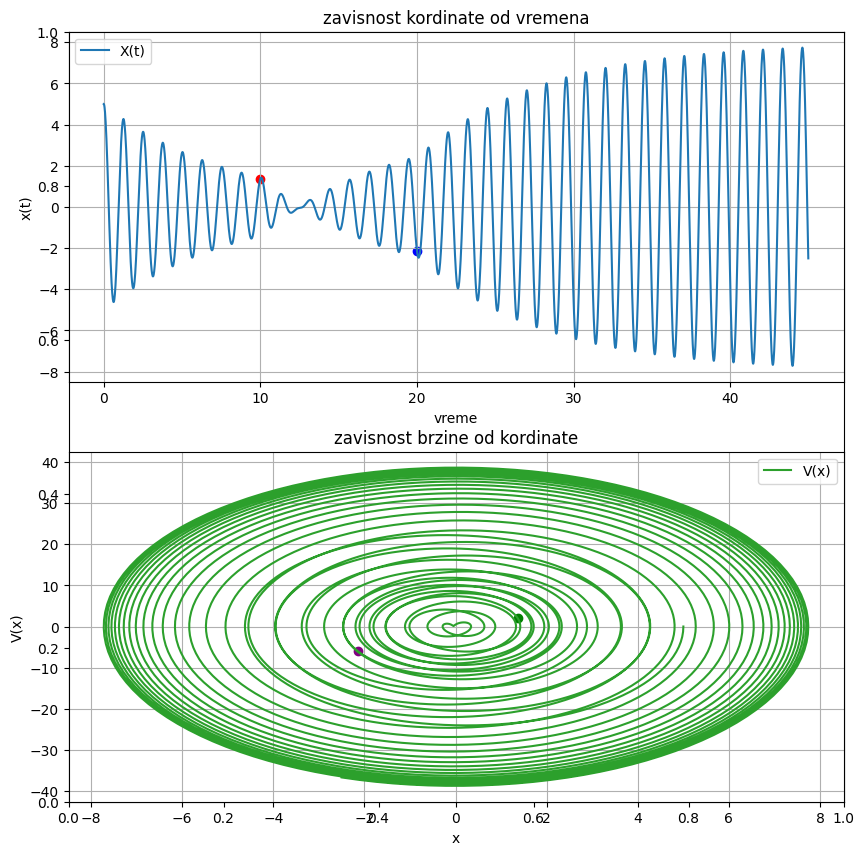

mesta na kom dolazi do promene su 1.3663562455600817 i -2.136150332284923, a brzine su 1.3663562455600817 i -6.043758978978501


In [21]:
time = np.arange(0,45,0.01)
v0=0
m=2
k=50
omega0=np.sqrt(k/m)
alpha=omega0/40
t1=10
t2=20
F01=10
F02=20
omegaPrinudno=5
x0=5
elongacije=[]
indeksi_elongacija=[]
sol= integrate.odeint(lho,[x0,v0],time,args=(omega0,alpha,omegaPrinudno,t1,t2,m,F01,F02))
for i,t in enumerate(time):
    if t==10:
        elongacije.append(sol[:,0][i])
        indeksi_elongacija.append(i)
    if t==20:
        elongacije.append(sol[:,0][i])
        indeksi_elongacija.append(i)
        break
plt.figure(figsize=(10,10))
plt.title("zavisnost kordinate od vremena")
plt.subplot(2,1,1)
plt.plot(time,sol[:,0],label="X(t)")
plt.xlabel('vreme')
plt.ylabel('x(t)')
plt.grid()
plt.legend()

plt.scatter([t1],elongacije[0],marker="o",color="red")
plt.scatter([t2],elongacije[1],marker="o",color="blue")
plt.subplot(2,1,2)
plt.plot(2,1,2)
plt.title("zavisnost brzine od kordinate")
plt.plot(sol[:,0],sol[:,1],label="V(x)")
plt.legend()
plt.grid()
v1=sol[:,0][indeksi_elongacija[0]]
v2=sol[:,1][indeksi_elongacija[1]]
plt.scatter([sol[:,0][indeksi_elongacija[0]]],[sol[:,1][indeksi_elongacija[0]]],marker="o",color="green")
plt.scatter([sol[:,0][indeksi_elongacija[1]]],[sol[:,1][indeksi_elongacija[1]]],marker="o",color="purple")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.show()
print(f"mesta na kom dolazi do promene su {elongacije[0]} i {elongacije[1]}, a brzine su {v1} i {v2}")

c) Šta se dešava sa telom posle dovoljno dugog vremena? Komentarisati dobijeni vremenski i fazni dijagram, objasniti na koji način se prikazuju različiti režimi oscilovanja na ovim graficima. Kog je oblika fazni dijagram i šta se sve uočava na njemu?

Imamo dva dijagrama vremenski i fazni, vremenski dijagram pocinje u x0=5, pa amplituda krene da mu opada, nakon toga kada se pojavi prinudna sila, pa amplituda krene da se povecava, pa se nakon toga dostigne vremenski trenutak 20s gde se jos vise povecava amplituda.
Fazni grafik je oblika elipse na pocetku brzina opada jer je rec o prigusenom kretanju linearnog harmonijskog oscilatora, brzina opada i oscilator je sve blizi mirovanju a koordinata je sve bliza ravnoteznom polozaju. Nakon toga dolazi prinudna sila, pa se brzina povecava (zato i ova elpipsa pocinje malo da lici na krug), i onda kada dodje jos veca prinudna sila krene jos malo vise da lici na krug. Nakon dovoljno dugog vremena ce ostati samo elipsa koja ce se kretati u jednoj konstantnoj elipsi, jer ce na kretanje uticati samo prinudna sila.

d) Napisati program koji za posmatrano kretanje tela izračunava i iscrtava potencijalnu energiju oscilatora, kao i kinetičku energiju u zavisnosti od koordinate $x$. Grafike energija nacrtati u istom koordinatnom sistemu, različitim bojama. Obeležiti ose grafika, dodati naslov i uneti legendu. Na grafik dodati mrežu (grid). 

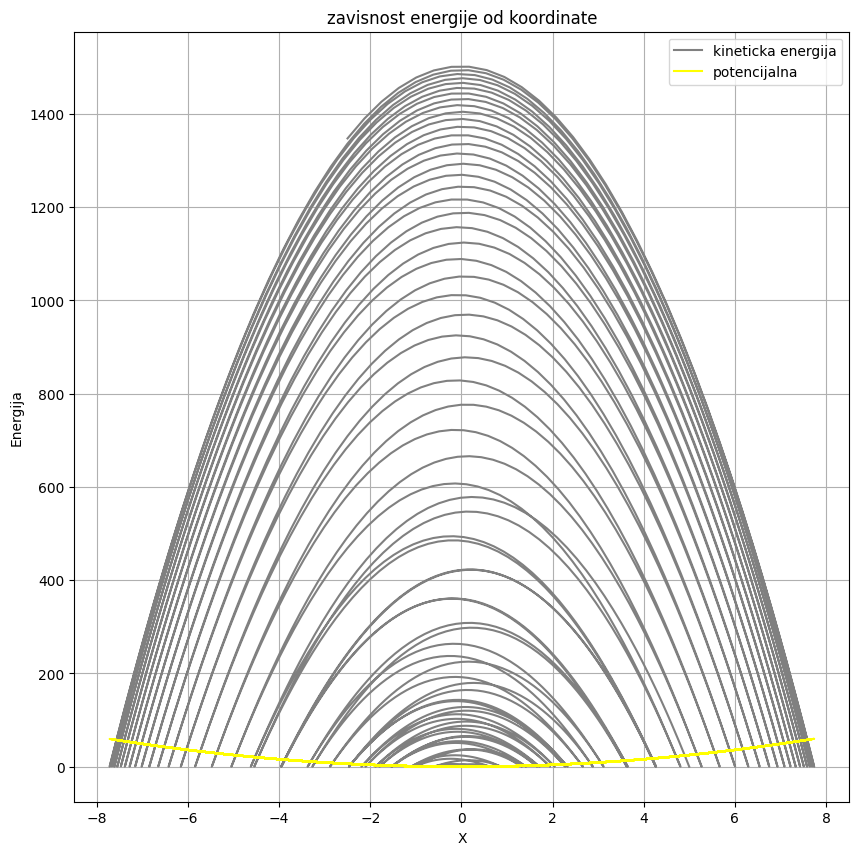

In [ ]:
Ep=0.5*k*sol[:,0]**2
Ek=0.5*m*sol[:,1]**2
plt.figure(figsize=(10,10))
plt.plot(sol[:,0],Ek,color="gray",label="kineticka energija")
plt.plot(sol[:,0],Ep,color="yellow",label="potencijalna energija")
plt.xlabel("X")
plt.ylabel("Energija")
plt.title("zavisnost energije od koordinate")
plt.legend()
plt.grid()
plt.show()

e) Objasniti zašto grafik kinetičke energije ima više linija, a grafik potencijalne samo jednu.

potencijalna energija zavisi od X koordinate, pa na grafiku koji prikazuje zavisnost energije od koordinate se dobija samo jedna kriva.
kineticka energija u drugu ruku zavisi od brzine, pa na grafiku koji prikazuje zavisnost energije od koordinate se dobija vise linija.

f) Napisati program koji automatski pronalazi sve maksimalne (pozitivne) vrednosti amplitude i vremenske trenutke u kojima se oni dostižu, pri čemu vrednosti amplituda treba spakovati u dva odvojena niza. S obzirom na to da je sistem na početku prigušen, očekivano je da amplitude oscilacija opadaju, a da zatim krenu da rastu, nakon što se uključuje prinudna sila. U niz "amplitude1" treba spakovati monotono opadajuće amplitude, a odgovarajuće vremenske trenutke u niz "vremena1". U niz "amplitude2" treba spakovati monotono rastuće amplitude, a odgovarajuće vremenske trenutke u niz "vremena2".  Nacrtati vremenski dijagram oscilacija (vremenski dijagram nacrtati plavom bojom) na kome su monotono opadajuće amplitude obeležene crvenim markerom, a monotono rastuće amplitude obeleženim zelenim markerom. Obeležiti ose grafika i dodati mrežu (grid). <font color='red'>Pitanje se računa kao odbrana prvog domaćeg zadatka.</font> 

<Figure size 640x480 with 0 Axes>

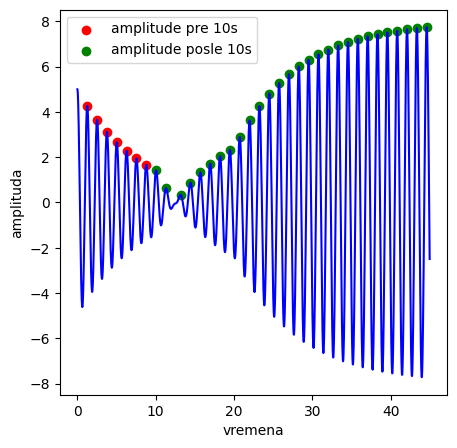

In [31]:
def maksimumi(sol,time):
    vremena1=[]
    vremena2=[]
    amplitude1=[]
    amplitude2=[]
    x=sol[:,0]
    for i in range(1,len(x)-1):
        if x[i-1]<x[i]>x[i+1] and i<1000:
            amplitude1.append(x[i])
            vremena1.append(time[i])
        elif x[i-1]<x[i]>x[i+1] and i>1000:
            amplitude2.append(x[i])
            vremena2.append(time[i])
    return amplitude1,vremena1,amplitude2,vremena2
amplitude1,vremena1,amplitude2,vremena2=maksimumi(sol,time)
plt.clf()
plt.figure(figsize=(5,5))
plt.scatter(vremena1,amplitude1,marker="o",color="red",label="amplitude pre 10s")
plt.scatter(vremena2,amplitude2,marker="o",color="green",label="amplitude posle 10s")
plt.plot(time,sol[:,0],color = 'blue')
plt.xlabel("vremena")
plt.ylabel("amplituda")
plt.legend()
plt.show()
#ovde sam uzeo u obzir da pocetno stanje nije amplituda

g) Za niz amplituda u nizu "amplitude2" metodom fitovanja provući krivu koja opisuje logističku funkciju, pri čemu su vrednosti na apsici translirane vrednosti iz niza "vremena2", tako da početni trenutak u  bude 0 s (prvoj amplitudi u nizu "amplituda2" sada odgovara vremenski trenutak od 0 s). Prikazati dobijenu krivu zelenom bojom, a tačke upotrebljene za fitovanje crvenom bojom.

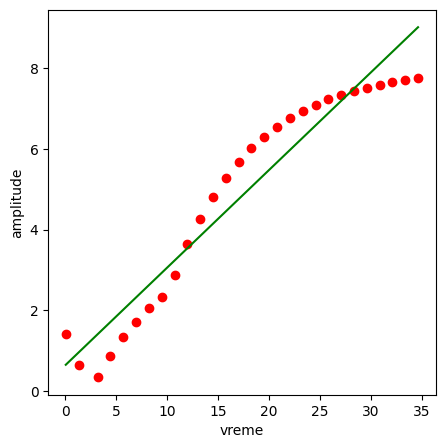

In [ ]:
from scipy.optimize import curve_fit
def linear(x,a,b):
    return a*x+b

koef, cov, *rest = curve_fit(linear,vremena2,amplitude2)
a=koef[0]
b=koef[1]

plt.figure(figsize=(5,5))
fitovane_amplitude=[]
for vreme in vremena2:
    fitovane_amplitude.append(linear(vreme,a,b))
plt.plot(vremena2-np.array([10]), fitovane_amplitude, color='green')
plt.scatter(vremena2-np.array([10]),amplitude2,color="red")
plt.xlabel("vreme")
plt.ylabel("amplitude")
plt.show()
#dovoljno je samo da se oduzme koordinata vremena za t1

h) Umesto korišćenja ugrađenih scipy metoda integracije, reprodukovati grafike dobijene u tački b) rešavanjem odgovarajuće diferencijalne jednačine pomoću FDM metode. <font color='red'>Pitanje se računa kao odbrana prvog domaćeg zadatka.</font> 

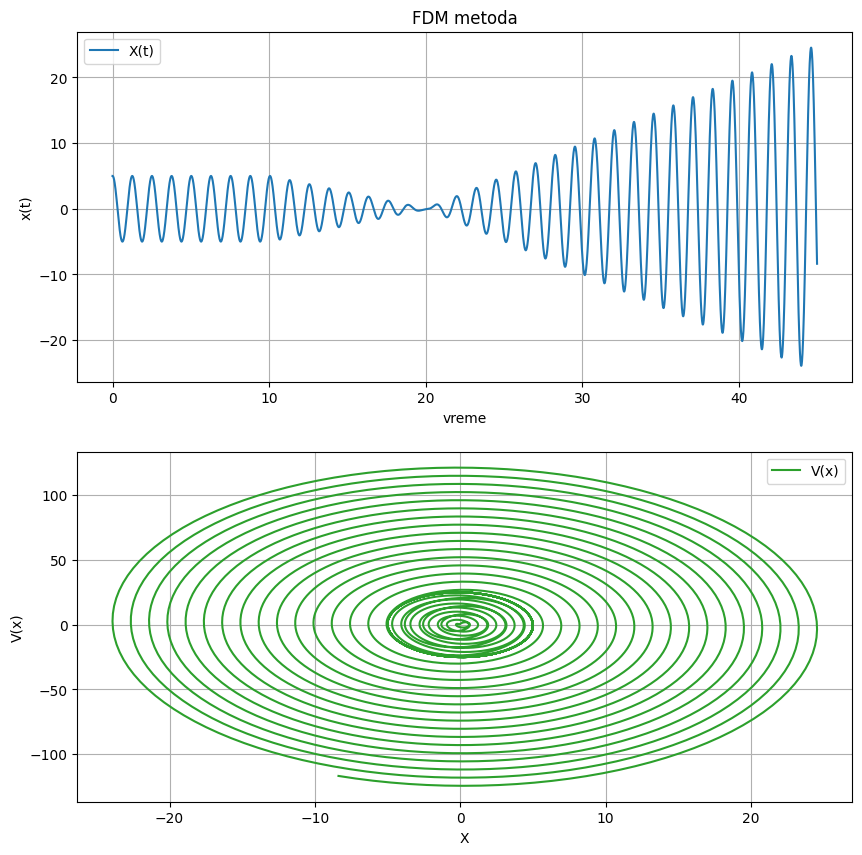

In [35]:
n=4500
k=2
matrica=np.zeros((n,2))
matrica[0,0]=5
matrica[0,1]=0

delta_t=0.01
for i in range(1,n):
    if time[i]<t1:
        matrica[i,0]=matrica[i-1,0]+delta_t*matrica[i-1,1]
        matrica[i,1]=matrica[i-1,1]+delta_t*(-(omega0**2)*matrica[i-1,0]-2*alpha*matrica[i-1][1])
    elif t1<time[i]<t2:
        matrica[i,0]=matrica[i-1,0]+delta_t*matrica[i-1,1]
        matrica[i,1]=matrica[i-1,1]+delta_t*(F01/m*np.sin(omegaPrinudno*time[i])-(omega0**2)*matrica[i-1,0]-2*alpha*matrica[i-1,1])
    else:
        matrica[i,0]=matrica[i-1,0]+delta_t*matrica[i-1,1]
        matrica[i,1]=matrica[i-1,1]+delta_t*(F02/m*np.sin(omegaPrinudno*time[i])-(omega0**2)*matrica[i-1,0]-2*alpha*matrica[i-1,1])
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.title("FDM metoda")
plt.plot(time,matrica[:,0],label="X(t)")
plt.xlabel('vreme')
plt.ylabel('x(t)')
plt.grid()
plt.legend()

plt.subplot(2,1,2)
plt.plot(2,1,2)
plt.plot(matrica[:,0],matrica[:,1],label="V(x)")
plt.xlabel("X")
plt.ylabel("V(x)")
plt.legend()

plt.grid()
